NOTEBOOK 1: RQ1 - BASELINE PERFORMANCE
Car Price Prediction using AutoScout24 Dataset

[1] Loading dataset...
✅ Loaded: autoscout24_16and10200.csv
Dataset shape: (10200, 16)

[2] Cleaning data...
Rows after cleaning: 10,200

[3] Preparing features and target...
Features: ['mileage_km', 'power_hp', 'vehicle_age', 'brand_premium', 'weight_kg', 'cylinders_volume_cc', 'nr_doors']
Target: price

[4] Train-test split...
Training: 8,160, Test: 2,040

[5] Feature scaling...
✅ Scaling complete

[6] Training baseline models...
  Training Linear Regression...
    R² = 0.5678
  Training Decision Tree...
    R² = 0.8771
  Training k-NN (k=5)...
    R² = 0.8838

[7] Creating Table I...

----------------------------------------------------------------------
TABLE I: Baseline Model Performance
----------------------------------------------------------------------
Model                MAE (€)         RMSE (€)        R²        
----------------------------------------------------------------------
Linea

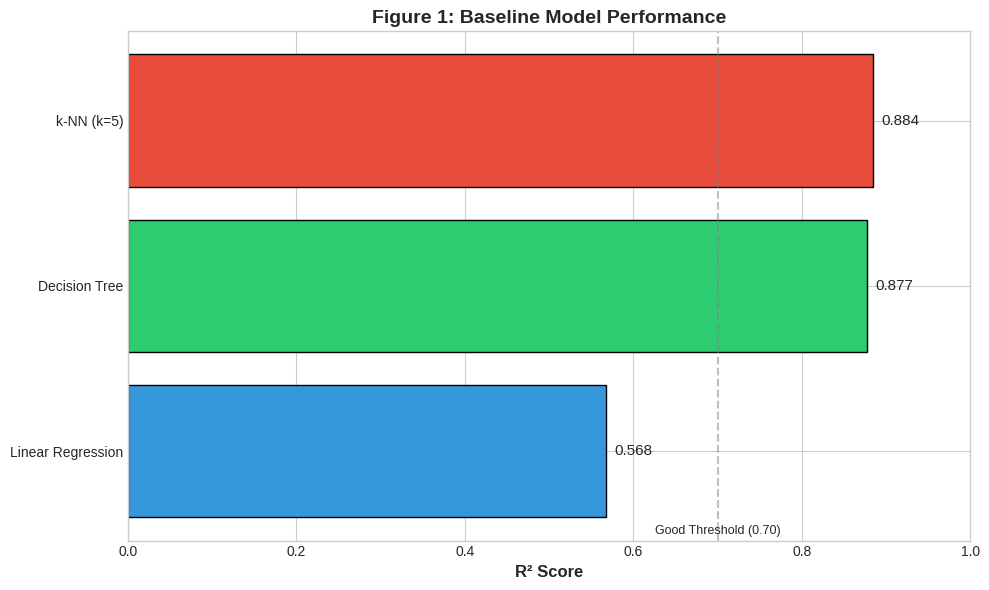

✅ Saved: /kaggle/working/Figure1_Baseline_Performance.pdf

NOTEBOOK 1 COMPLETE

🏆 Best Baseline: k-NN (k=5)
   R² = 0.8838

📁 Output saved to: /kaggle/working


In [1]:
# ==============================================================================
# NOTEBOOK 1: RQ1 - BASELINE PERFORMANCE
# Dataset: autoscout24_16and10200
# Kernel: cars-marketanalysis-rq1
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("=" * 70)
print("NOTEBOOK 1: RQ1 - BASELINE PERFORMANCE")
print("Car Price Prediction using AutoScout24 Dataset")
print("=" * 70)

# ==============================================================================
# LOAD DATASET
# ==============================================================================
print("\n[1] Loading dataset...")

input_dir = '/kaggle/input'
df = None

for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith('.csv') and ('autoscout24' in file.lower() or '16and10200' in file):
            df = pd.read_csv(os.path.join(root, file))
            print(f"✅ Loaded: {file}")
            break
    if df is not None:
        break

if df is None:
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.endswith('.csv'):
                df = pd.read_csv(os.path.join(root, file))
                print(f"✅ Loaded: {file}")
                break
        if df is not None:
            break

print(f"Dataset shape: {df.shape}")

# ==============================================================================
# CLEAN DATA
# ==============================================================================
print("\n[2] Cleaning data...")

def clean_mileage(value):
    if isinstance(value, str):
        cleaned = re.sub(r'[^\d.]', '', value.replace(',', ''))
        try:
            return float(cleaned)
        except:
            return np.nan
    return value

def clean_weight(value):
    if isinstance(value, str):
        cleaned = re.sub(r'[^\d.]', '', value.replace(',', ''))
        try:
            return float(cleaned)
        except:
            return np.nan
    return value

if 'mileage_km' in df.columns:
    df['mileage_km'] = df['mileage_km'].apply(clean_mileage)
if 'weight_kg' in df.columns:
    df['weight_kg'] = df['weight_kg'].apply(clean_weight)

numeric_cols = ['power_hp', 'power_kw', 'cylinders_volume_cc', 'nr_doors', 'vehicle_age', 'brand_premium']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing values
df_clean = df.dropna()
print(f"Rows after cleaning: {df_clean.shape[0]:,}")

# ==============================================================================
# PREPARE FEATURES AND TARGET
# ==============================================================================
print("\n[3] Preparing features and target...")

target_col = 'price'
y = df_clean[target_col]

# Select numeric features for baseline
feature_cols = ['mileage_km', 'power_hp', 'vehicle_age', 'brand_premium', 
                'weight_kg', 'cylinders_volume_cc', 'nr_doors']
available_features = [f for f in feature_cols if f in df_clean.columns]
X = df_clean[available_features]

print(f"Features: {available_features}")
print(f"Target: {target_col}")

# ==============================================================================
# TRAIN-TEST SPLIT
# ==============================================================================
print("\n[4] Train-test split...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}")

# ==============================================================================
# FEATURE SCALING
# ==============================================================================
print("\n[5] Feature scaling...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ Scaling complete")

# ==============================================================================
# TRAIN BASELINE MODELS
# ==============================================================================
print("\n[6] Training baseline models...")

def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'k-NN (k=5)': KNeighborsRegressor(n_neighbors=5)
}

results = []
for name, model in models.items():
    print(f"  Training {name}...")
    result = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, name)
    results.append(result)
    print(f"    R² = {result['R2']:.4f}")

# ==============================================================================
# CREATE TABLE I
# ==============================================================================
print("\n[7] Creating Table I...")

results_df = pd.DataFrame(results)

print("\n" + "-" * 70)
print("TABLE I: Baseline Model Performance")
print("-" * 70)
print(f"{'Model':<20} {'MAE (€)':<15} {'RMSE (€)':<15} {'R²':<10}")
print("-" * 70)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<20} €{row['MAE']:>12,.0f} €{row['RMSE']:>12,.0f} {row['R2']:>10.4f}")
print("-" * 70)

output_dir = '/kaggle/working'
results_df.to_csv(f'{output_dir}/TableI_Baseline_Performance.csv', index=False)
print(f"\n✅ Saved: {output_dir}/TableI_Baseline_Performance.csv")

# ==============================================================================
# CREATE FIGURE 1
# ==============================================================================
print("\n[8] Creating Figure 1...")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax.barh(results_df['Model'], results_df['R2'], color=colors, edgecolor='black')

ax.set_xlim(0, 1)
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Figure 1: Baseline Model Performance', fontsize=14, fontweight='bold')

for bar, score in zip(bars, results_df['R2']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{score:.3f}', va='center', fontsize=11)

ax.axvline(x=0.70, color='gray', linestyle='--', alpha=0.5)
ax.text(0.70, -0.5, 'Good Threshold (0.70)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{output_dir}/Figure1_Baseline_Performance.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{output_dir}/Figure1_Baseline_Performance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_dir}/Figure1_Baseline_Performance.pdf")

# ==============================================================================
# SUMMARY
# ==============================================================================
print("\n" + "=" * 70)
print("NOTEBOOK 1 COMPLETE")
print("=" * 70)
print(f"\n🏆 Best Baseline: {results_df.iloc[results_df['R2'].argmax()]['Model']}")
print(f"   R² = {results_df['R2'].max():.4f}")
print(f"\n📁 Output saved to: {output_dir}")
print("=" * 70)